In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

Loading and Cleaning Data with required columns

In [2]:
# Load the dataset
file_path = 'h243.xlsx'
df = pd.read_excel(file_path)


In [3]:
print('Dataframe shape:',df.shape)
print('Dataframe head:',df.head())
print('Dataframe info:',df.info())

Dataframe shape: (22431, 1420)
Dataframe head:       DUID  PID    DUPERSID  PANEL  DATAYEAR FAMID31 FAMID42 FAMID53 FAMID22  \
0  2460002  101  2460002101     24      2022       A       A       A       A   
1  2460006  101  2460006101     24      2022       A       A       A       A   
2  2460006  102  2460006102     24      2022       A       A       A       A   
3  2460010  101  2460010101     24      2022       A       A       A       A   
4  2460018  101  2460018101     24      2022       A       A       A       A   

  FAMIDYR  ... RXOSR22  RXPTR22  RXOTH22      PERWT22F      FAMWT22F  \
0       A  ...       0        0        0   5728.309495   5232.211986   
1       A  ...       0        0        0  15648.881461  16017.881691   
2       A  ...       0        0        0  14123.720178  16017.881691   
3       A  ...       0     5288      299  16982.054917  21905.758877   
4       A  ...       0       10        0  10682.619947  11344.291012   

       FAMWT22C      SAQWT22F     DIABW

In [4]:
# Selecting only relevant columns
columns_to_use = [
    'AGE42X', 'SEX', 'RACEV1X', 'REGION42', 'INSCOV22',
    'CHDDX', 'ANGIDX', 'MIDX', 'STRKDX'
]

# Filter the dataframe
df = df[columns_to_use]

# Fill missing values with median (for numeric features)
df = df.fillna(df.median(numeric_only=True))

# Rename columns for readability
df = df.rename(columns={
    'AGE42X': 'Age',
    'SEX': 'Sex',
    'RACEV1X': 'Race',
    'REGION42': 'Region',
    'INSCOV22': 'Insurance_Status',
    'CHDDX': 'Heart_Disease',
    'ANGIDX': 'Angina',
    'MIDX': 'Heart_Attack',
    'STRKDX': 'Stroke'
})

Step 1: Exploratory Data Analysis (EDA)

In [5]:
from capstone_group12 import create_display_copy

df_display = create_display_copy(df)
df_display.head()

,Age,Sex,Race,Region,Insurance_Status,Heart_Disease,Angina,Heart_Attack,Stroke,Sex_Label,Insurance_Label,Race_Label,Region_Label,Heart_Disease_Label,Stroke_Label,Angina_Label,Heart_Attack_Label
0,77,2,2,2,2,2,2,2,1,Female,Public,Black,Midwest,No,Yes,No,No
1,63,2,1,2,2,2,2,1,2,Female,Public,White,Midwest,No,No,No,Yes
2,67,1,1,2,2,2,2,2,2,Male,Public,White,Midwest,No,No,No,No
3,29,1,6,4,1,2,2,2,2,Male,Private,Multiple,West,No,No,No,No
4,51,2,1,1,1,2,2,2,2,Female,Private,White,Northeast,No,No,No,No


In [6]:
# -------descriptive analysis


print("Shape of dataset:", df.shape)
print("\nSummary statistics:")
print(df.describe())

# Generate cross-tab: Insurance type vs. Stroke status (labelled)
ct = pd.crosstab(
    df_display['Insurance_Label'],
    df_display['Stroke_Label'],
    dropna=False
).fillna(0).astype(int)

# Display the result
print(ct)

Shape of dataset: (22431, 9)

Summary statistics:
                Age           Sex          Race        Region  \
count  22431.000000  22431.000000  22431.000000  22431.000000   
mean      42.794971      1.527083      1.548304      2.700325   
std       24.059239      0.499277      1.200153      1.077422   
min       -1.000000      1.000000      1.000000     -1.000000   
25%       22.000000      1.000000      1.000000      2.000000   
50%       44.000000      2.000000      1.000000      3.000000   
75%       63.000000      2.000000      2.000000      4.000000   
max       85.000000      2.000000      6.000000      4.000000   

       Insurance_Status  Heart_Disease        Angina  Heart_Attack  \
count      22431.000000   22431.000000  22431.000000  22431.000000   
mean           1.490170       1.330748      1.364406      1.350007   
std            0.626989       1.268733      1.265816      1.258464   
min            1.000000      -8.000000     -8.000000     -8.000000   
25%           

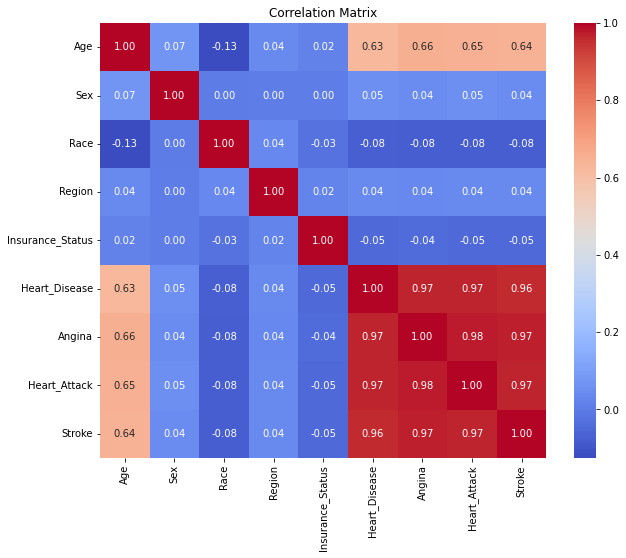

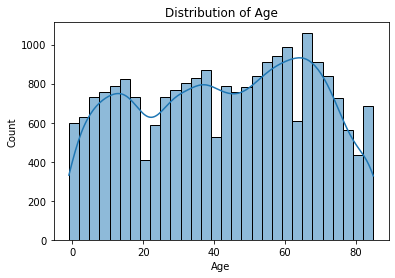

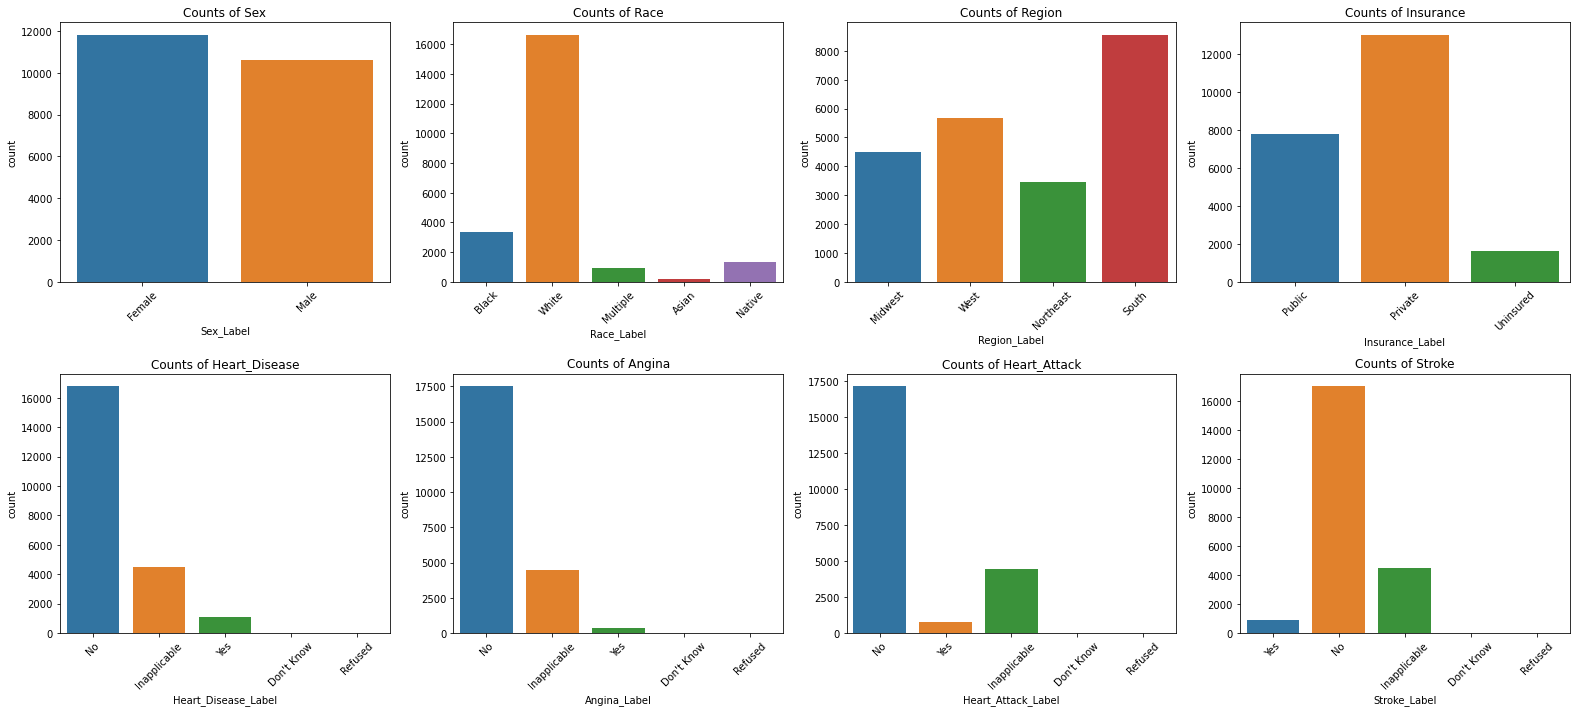

In [7]:
# ---------visualization
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Distributions
for col in ['Age']:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Categorical counts
# List of categorical columns using the readable versions
categorical_cols = ['Sex_Label', 'Race_Label', 'Region_Label', 'Insurance_Label',
                    'Heart_Disease_Label', 'Angina_Label', 'Heart_Attack_Label', 'Stroke_Label']

# Create 2x4 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 10))
axes = axes.flatten()


for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df_display, ax=axes[i])
    axes[i].set_title(f'Counts of {col.replace("_Label", "")}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Predictive Modelling

Predictive Model - Hospitalization Risk (Stroke as Proxy)

In [8]:
# Function 2: Keep only rows with "Yes" or "No" (1 or 2) for disease variables(will update in py later)
#def filter_binary_disease_responses(df, disease_vars):
    #return df[df[disease_vars].apply(lambda row: row.isin([1, 2]).all(), axis=1)].copy()


              precision    recall  f1-score   support

           1       0.12      0.73      0.21       187
           2       0.98      0.71      0.82      3393

    accuracy                           0.71      3580
   macro avg       0.55      0.72      0.52      3580
weighted avg       0.93      0.71      0.79      3580



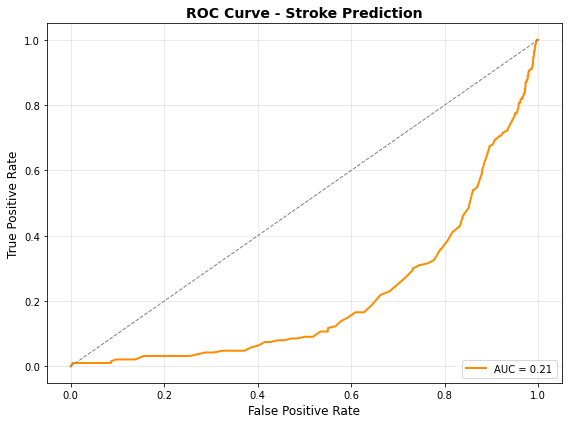

In [9]:
from capstone_group12 import filter_binary_disease_responses, run_logistic_regression

# Define disease columns
disease_columns = ['Heart_Disease', 'Angina', 'Heart_Attack', 'Stroke']

# Filter for valid responses (keep only Yes = 1 and No = 2)
df_filtered = filter_binary_disease_responses(df, disease_columns)

# Ensure disease columns are integers (important for ROC label logic)
df_filtered[disease_columns] = df_filtered[disease_columns].astype(int)

# Define features and target
X = df_filtered[['Age', 'Heart_Disease', 'Angina', 'Heart_Attack']]
y = df_filtered['Stroke']

# Run logistic regression 
clf, X_test, y_test, report = run_logistic_regression(X, y)

# Print performance report
print(report)

# ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Stroke Prediction", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Classification Report (After Upsampling):
              precision    recall  f1-score   support

           1       0.11      0.75      0.20       177
           2       0.98      0.70      0.82      3403

    accuracy                           0.70      3580
   macro avg       0.55      0.72      0.51      3580
weighted avg       0.94      0.70      0.79      3580



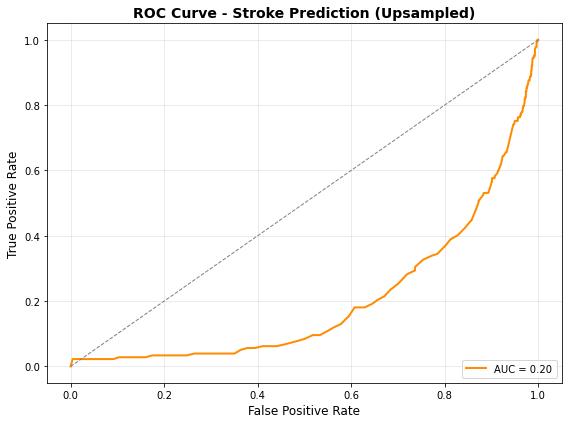

In [12]:
# Import packages
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.utils import resample
import matplotlib.pyplot as plt

# Assume df_filtered is already cleaned and filtered
# Define predictors and target
X = df_filtered[['Age', 'Heart_Disease', 'Angina', 'Heart_Attack']]
y = df_filtered['Stroke']

# Split before resampling (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Concatenate for upsampling
train_data = pd.concat([X_train, y_train], axis=1)

# Separate majority and minority classes
majority = train_data[train_data['Stroke'] == 2]
minority = train_data[train_data['Stroke'] == 1]

# Upsample minority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine and shuffle
upsampled = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=42)
X_train_balanced = upsampled.drop('Stroke', axis=1)
y_train_balanced = upsampled['Stroke']

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_balanced, y_train_balanced)

# Predict probabilities
y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

# Classification report
y_pred = clf.predict(X_test)
print("\nClassification Report (After Upsampling):")
print(classification_report(y_test, y_pred))

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Stroke Prediction (Upsampled)", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Logistic Regression Report (Insurance Status Prediction):
              precision    recall  f1-score   support

           0       0.13      0.64      0.21       291
           1       0.95      0.62      0.75      3289

    accuracy                           0.62      3580
   macro avg       0.54      0.63      0.48      3580
weighted avg       0.88      0.62      0.71      3580



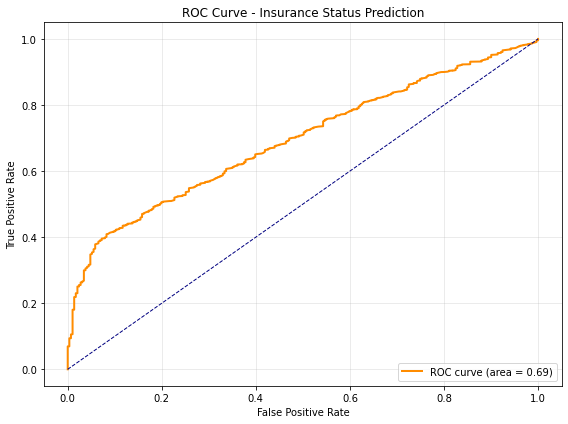

In [14]:
from capstone_group12 import filter_binary_disease_responses, run_logistic_regression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Define disease variables
disease_columns = ['Heart_Disease', 'Angina', 'Heart_Attack', 'Stroke']

# Filter for valid disease responses (Yes/No only)
df_filtered = filter_binary_disease_responses(df, disease_columns)

# Define features and binary target (1 = Insured [Private/Public], 0 = Uninsured)
X = df_filtered[['Age', 'Sex', 'Race', 'Region', 'Stroke', 'Heart_Disease', 'Angina', 'Heart_Attack']]
y = df_filtered['Insurance_Status'].apply(lambda x: 1 if x in [1, 2] else 0)

# Train and evaluate using the custom logistic regression function
clf, X_test, y_test, report = run_logistic_regression(X, y)
print("\nLogistic Regression Report (Insurance Status Prediction):")
print(report)

# Generate and plot ROC curve
y_pred_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Insurance Status Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Clustering - Patient Segmentation based on Health Conditions

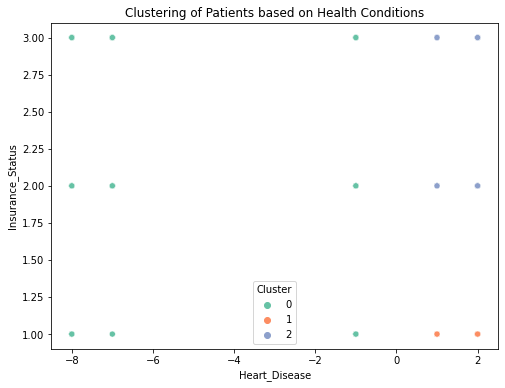


Cluster Centers:
[[-1.06969563 -1.05977062 -1.05183061 -1.05094839  1.5229378 ]
 [ 1.96049682  1.98552484  1.9748786   1.97114307  1.        ]
 [ 1.90666296  1.96814578  1.93406593  1.91973849  2.19961052]]


In [15]:
# Only using chronic conditions for clustering
cluster_data = df[['Heart_Disease', 'Angina', 'Heart_Attack', 'Stroke','Insurance_Status']]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(cluster_data)

# Add cluster labels to dataframe
df['Cluster'] = kmeans_labels

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Heart_Disease', y='Insurance_Status', hue='Cluster', data=df, palette='Set2')
plt.title('Clustering of Patients based on Health Conditions')
plt.show()

print("\nCluster Centers:")
print(kmeans.cluster_centers_)


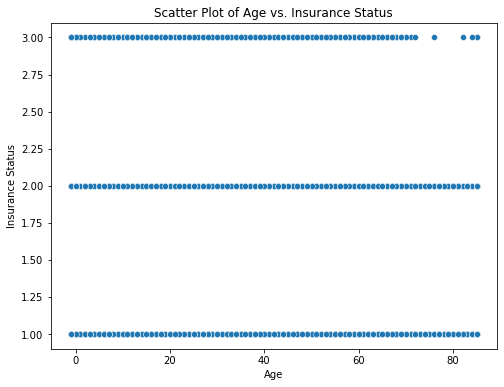

In [16]:
# prompt: a scatter plot with age as the dependent variable

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Insurance_Status', data=df)
plt.xlabel('Age')
plt.ylabel('Insurance Status')
plt.title('Scatter Plot of Age vs. Insurance Status')
plt.show()


Best number of clusters based on silhouette score: 3


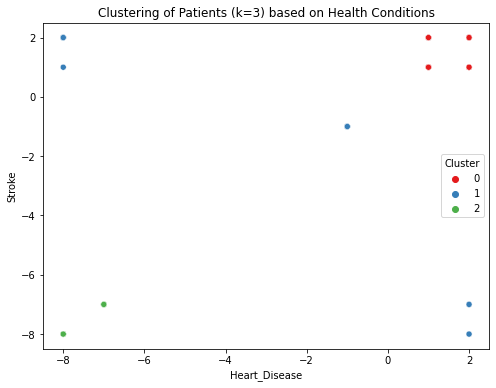


Cluster Centers (scaled):
[[ 0.47932741  0.48518221  0.48351925  0.48262812]
 [-1.84745418 -1.87039396 -1.86351357 -1.8617098 ]
 [-7.03118152 -7.07397664 -7.10385832 -6.90281802]]


In [17]:
#Import the StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

cluster_data = df[['Heart_Disease', 'Angina', 'Heart_Attack', 'Stroke']]

# Scale the data
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Determine the best number of clusters using silhouette score
sil_scores = {}
for k in range(2, 6):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(cluster_data_scaled)
    sil_score = silhouette_score(cluster_data_scaled, labels)
    sil_scores[k] = sil_score

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest number of clusters based on silhouette score: {best_k}")

# Final KMeans with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(cluster_data_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Heart_Disease', y='Stroke', hue='Cluster', data=df, palette='Set1')
plt.title(f'Clustering of Patients (k={best_k}) based on Health Conditions')
plt.show()

print("\nCluster Centers (scaled):")
print(kmeans.cluster_centers_)
